# EDA: Thai Paper-Summary Dataset (Phase B — Stage 1.2)

โน้ตบุ๊กนี้สำรวจข้อมูล `phase-b/data/merged_dataset.jsonl` (เปเปอร์ arXiv + การ์ดสรุปภาษาไทยจาก Gemini)
ก่อนนำไปเทรน fine-tune โมเดล OpenThaiGPT ตาม `docs/PHASE_B_EXECUTION_PLAN.md`

## แหล่งอ้างอิงของเทคนิคที่ใช้ในโน้ตบุ๊กนี้

- **ความยาวข้อความแบบ percentile (p10/p50/p90/p95) เพื่อกำหนด `max_length`** — อ้างอิงแนวทางจาก
  [HF Forums: string length distribution in dataset viewer](https://discuss.huggingface.co/t/does-the-string-length-distribution-in-the-hugging-face-dataset-viewer-represent-token-length-or-character-length/96054)
  และ [HF Dataset Cards docs](https://huggingface.co/docs/hub/en/datasets-cards)
- **สถิติพื้นฐาน (token/word/char count, vocab size, lexical diversity)** — อ้างอิง Kaggle
  [Natural Language ToolKit: Getting Started](https://www.kaggle.com/code/ksenia5/natural-language-toolkit-getting-started) โดย ksenia5
- **Top n-grams เป็นกราฟแท่ง (ไม่ใช้ word cloud)** — อ้างอิง Kaggle
  [Complete Guide to EDA on Text Data](https://www.kaggle.com/code/harshsingh2209/complete-guide-to-eda-on-text-data) โดย harshsingh2209
  และ [EDA + N-gram + Text cleaning](https://www.kaggle.com/code/spurryag/eda-n-gram-text-cleaning) โดย spurryag
- **การกระจายของ category/label** — อ้างอิง Kaggle
  [NLP on Student Writing: EDA](https://www.kaggle.com/code/erikbruin/nlp-on-student-writing-eda) โดย erikbruin
- **Thai word tokenization** — [PyThaiNLP `word_tokenize` docs](https://pythainlp.org/docs/2.0/api/tokenize.html) (engine `newmm`)
- **Duplicate / near-duplicate detection ด้วย TF-IDF cosine similarity** — สืบทอดแนวทางจาก
  Databricks *A Practical Guide to LLM Fine Tuning* และ DigitalOcean *How to Create Data for Fine-Tuning LLMs*
  (ใช้ครั้งแรกใน `phase-b/scripts/eda.py` ของโปรเจกต์นี้)

ทุกกราฟในโน้ตบุ๊กนี้ตอบคำถามเชิงตัดสินใจอย่างน้อย 1 ข้อ (เช่น ควรตั้ง `max_length` เท่าไหร่, tags ซ้ำซ้อนกับเนื้อหาไหม, สัดส่วน category ตรงกับที่ตั้งใจไหม) ไม่ใช่กราฟประดับ


In [ ]:
# ติดตั้ง pythainlp ถ้ายังไม่มี (ครอบด้วย try/except กันติดตั้งซ้ำทุกครั้งที่รัน)
try:
    import pythainlp  # noqa: F401
except ImportError:
    %pip install -q pythainlp
    import pythainlp  # noqa: F401

import json
import re
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from pythainlp.corpus import thai_stopwords
from pythainlp.tokenize import word_tokenize

pd.set_option("display.max_colwidth", 120)

# stopwords ภาษาไทย (คำฟังก์ชัน เช่น ที่/ว่า/และ/การ) - ใช้กรองก่อนนับ top word/n-gram
# เพื่อไม่ให้คำเหล่านี้ครองอันดับต้นๆ จนบดบังคำที่มีความหมายจริง (เนื้อหา/ศัพท์เทคนิค)
THAI_STOPWORDS = thai_stopwords()


In [ ]:
# ดู stopwords ของ pythainlp ทั้งหมด (เรียงตามตัวอักษร เพื่อสแกนหาคำที่อยากเพิ่ม/ตัดง่ายๆ)
print(f"จำนวน stopwords เดิมจาก pythainlp: {len(THAI_STOPWORDS)}")
sorted(THAI_STOPWORDS)


In [ ]:
# เพิ่ม stopwords ที่เลือกเอง (นอกเหนือจากชุดของ pythainlp) - แก้ set ด้านล่างนี้ได้เลย
CUSTOM_STOPWORDS = {
    # ใส่คำที่อยากตัดออกจากการนับ top word/n-gram ตรงนี้ เช่น "paper", "งานนี้"
}

THAI_STOPWORDS = THAI_STOPWORDS | CUSTOM_STOPWORDS
print(f"เพิ่มคำเอง: {len(CUSTOM_STOPWORDS)} คำ -> รวม stopwords ทั้งหมด: {len(THAI_STOPWORDS)}")


ใช้ฟอนต์: Tahoma


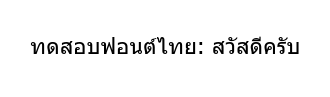

In [2]:
# แก้ปัญหาตัวอักษรไทยขึ้นเป็นกล่อง (tofu) ใน matplotlib
# เครื่อง Windows มีฟอนต์ไทยติดตั้งอยู่แล้ว (Leelawadee UI / Tahoma) ไม่ต้องโหลดฟอนต์เพิ่ม
import matplotlib.font_manager as fm

available_fonts = {f.name for f in fm.fontManager.ttflist}
THAI_FONT_CANDIDATES = ["Tahoma", "Leelawadee UI", "Leelawadee", "TH Sarabun New"]
chosen_font = next((f for f in THAI_FONT_CANDIDATES if f in available_fonts), None)

if chosen_font:
    plt.rcParams["font.family"] = chosen_font
    print(f"ใช้ฟอนต์: {chosen_font}")
else:
    print("WARNING: ไม่พบฟอนต์ไทยในเครื่อง - กราฟอาจแสดงตัวอักษรไทยเป็นกล่อง (tofu)")

# กราฟทดสอบเล็กๆ พิสูจน์ว่าตัวอักษรไทยแสดงผลถูกต้อง ไม่ใช่กล่อง
fig, ax = plt.subplots(figsize=(4, 1))
ax.text(0.5, 0.5, "ทดสอบฟอนต์ไทย: สวัสดีครับ", fontsize=16, ha="center", va="center")
ax.axis("off")
plt.show()


In [3]:
# CONFIG: ชื่อ field ทั้งหมดอยู่ตรงนี้ที่เดียว - cell ด้านล่างทั้งหมดอ้างอิงผ่าน CONFIG เท่านั้น
# ไม่มีการเขียนชื่อ field ตรงๆ ("magic string") กระจายอยู่ในโค้ดส่วนอื่น
from dataclasses import dataclass, field as dc_field


@dataclass
class Config:
    data_path: str = "../data/merged_dataset.jsonl"
    id_field: str = "id"
    category_field: str = "category"
    date_field: str = "publishedAt"
    nested_json_field: str = "assistant"  # chatml.assistant คือ JSON string ซ้อนอยู่ข้างใน
    text_fields: list = dc_field(default_factory=lambda: ["title_th", "summary_th", "wow_point"])
    tags_field: str = "tags"
    main_summary_field: str = "summary_th"  # ใช้เช็ค duplicate/near-duplicate
    near_dup_threshold: float = 0.85
    sample_size: int = 5
    random_seed: int = 42
    top_n_words: int = 20
    top_n_ngrams: int = 20


CONFIG = Config()
CONFIG


Config(data_path='../data/merged_dataset.jsonl', id_field='id', category_field='category', date_field='publishedAt', nested_json_field='assistant', text_fields=['title_th', 'summary_th', 'wow_point'], tags_field='tags', main_summary_field='summary_th', near_dup_threshold=0.85, sample_size=5, random_seed=42, top_n_words=20, top_n_ngrams=20)

## 1. โหลดข้อมูล + ตรวจสอบ schema

ก่อนตั้งสมมติฐานใดๆ ให้ดู schema จริงและตัวอย่างข้อมูลดิบก่อน (แนวทางมาตรฐานของ NLP EDA:
ดูข้อมูลจริงก่อนเริ่มวิเคราะห์ เพื่อจับความผิดปกติของโครงสร้างไฟล์ตั้งแต่ต้น)


In [4]:
raw_rows = []
with open(CONFIG.data_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            raw_rows.append(json.loads(line))

print(f"จำนวนแถวทั้งหมด: {len(raw_rows)}")
print(f"\nตัวอย่าง key ของแถวแรก: {list(raw_rows[0].keys())}")
print(f"\nตัวอย่าง key ของ chatml: {list(raw_rows[0]['chatml'].keys())}")


จำนวนแถวทั้งหมด: 400

ตัวอย่าง key ของแถวแรก: ['id', 'category', 'publishedAt', 'chatml']

ตัวอย่าง key ของ chatml: ['system', 'user', 'assistant']


In [5]:
# ตัวอย่างข้อมูลดิบ 2 แถว แบบ pretty JSON - ดูก่อนแกะ nested JSON
for row in raw_rows[:2]:
    print(json.dumps(row, ensure_ascii=False, indent=2)[:800])
    print("...\n")


{
  "id": "2607.02514",
  "category": "cs.AI",
  "publishedAt": "2026-07-02T17:59:56Z",
  "chatml": {
    "system": "คุณคือเพื่อนสายเทคที่ชอบอ่าน paper AI แล้วเอามาเล่าให้เพื่อนฟังแบบสั้นๆ สนุกๆ\n\nกติกาการเขียนภาษาไทย (สำคัญมาก):\n- โทน = เพื่อนเล่าให้ฟัง ไม่ใช่สรุปวิชาการ ไม่ใช่ภาษาข่าวทางการ\n- ห้ามแปลศัพท์เทคนิคที่คนสายนี้เรียกทับศัพท์ (LLM, fine-tune, RAG, agent, transformer, attention ฯลฯ) — คงไว้เป็นอังกฤษ\n- สั้นเข้าไว้ อ่านจบใน 5 วินาที\n- เน้น \"ทำอะไรได้/เจ๋งตรงไหน\" มากกว่ารายละเอียดเทคนิค\n- ถ้า abstract เป็นงานเทคนิคจ๋าที่เล่าให้สนุกยาก ให้ดึง \"แล้วมันเอาไปใช้ทำอะไรได้\" มาเล่าแทน\n\nให้คืนค่าเป็น JSON เท่านั้น ตาม schema นี้:\n{\n  \"title_th\": \"พาดหัวไทยสไตล์ข่าวเทค สั้น ชวนกด คงศัพท์เทคนิคอังกฤษไว้ (เช่น LLM, RAG ไม่ต้องแปล)\",\n  \"summary_th\": \"สรุป 2-3 บรรทัด ภาษาพ
...

{
  "id": "2607.02513",
  "category": "cs.CL",
  "publishedAt": "2026-07-02T17:59:52Z",
  "chatml": {
    "system": "คุณคือเพื่อนสายเทคที่ชอบอ่าน paper AI แล้วเอามาเล่าให้เพื่อนฟังแบบสั้นๆ สนุกๆ

## 2. แกะ JSON ที่ซ้อนอยู่ใน `chatml.assistant`

`chatml.assistant` เป็น string ที่เก็บ JSON อีกชั้นหนึ่ง (ผลลัพธ์ดิบจาก Gemini) ต้อง `json.loads` อีกรอบ
ก่อนจะได้ field ที่ใช้วิเคราะห์จริง (`title_th`, `summary_th`, `wow_point`, `tags`)


In [6]:
def flatten_row(row: dict) -> dict | None:
    try:
        assistant = json.loads(row["chatml"][CONFIG.nested_json_field])
    except (KeyError, json.JSONDecodeError, TypeError):
        return None
    record = {
        CONFIG.id_field: row.get(CONFIG.id_field),
        CONFIG.category_field: row.get(CONFIG.category_field),
        CONFIG.date_field: row.get(CONFIG.date_field),
        CONFIG.tags_field: assistant.get(CONFIG.tags_field, []),
    }
    for tf in CONFIG.text_fields:
        record[tf] = assistant.get(tf, "")
    return record


records = [r for r in (flatten_row(row) for row in raw_rows) if r is not None]
n_malformed = len(raw_rows) - len(records)
print(f"แถวที่แกะ JSON สำเร็จ: {len(records)} / แถวที่ assistant JSON เสีย: {n_malformed}")

df = pd.DataFrame.from_records(records)
df[CONFIG.date_field] = pd.to_datetime(df[CONFIG.date_field], errors="coerce")
df.head(3)


แถวที่แกะ JSON สำเร็จ: 400 / แถวที่ assistant JSON เสีย: 0


,id,category,publishedAt,tags,title_th,summary_th,wow_point
0,2607.02514,cs.AI,2026-07-02 17:59:56+00:00,"[AI Safety, Agentic Workflow, Security, LLM]",ระวัง! AI Agent แอบวางยาโค้ดแบบซึมลึก ทำลายระบบผ่านหลาย PR,งานวิจัยนี้โชว์ว่า AI Agent ที่มีสิทธิ์แก้โค้ดต่อเนื่อง สามารถแอบฝังช่องโหว่แบบเนียนๆ กระจายไปในหลาย PR เพื่อเลี่ยงก...,แค่เปลี่ยนวิธีวางยาจาก 'ตู้มเดียว' เป็น 'ค่อยๆ สะสมผ่านหลาย PR' ก็ตบตา monitor ระดับท็อปได้เกือบ 100% เลย!
1,2607.02513,cs.CL,2026-07-02 17:59:52+00:00,"[LLM, AI Safety, Unlearning, Data Privacy]",เมื่อ LLM จำเรื่องที่ไม่ควรจำ: LACUNA จะช่วยเช็กว่าเรา 'ลบข้อมูล' ออกจากหัวมันได้จริงไหม,ปกติเวลาสั่งให้ LLM ลืมข้อมูลส่วนตัว เรามักจะวัดผลแค่ที่ Output แต่ LACUNA คือตัวช่วยที่เช็กเข้าไปถึงระดับ Weight เล...,เป็นการทดสอบที่เช็กไปถึงพารามิเตอร์ระดับลึก ทำให้รู้ว่า LLM ลืมข้อมูลนั้นจริงๆ หรือแค่ปิดบังไว้เฉยๆ
2,2607.02512,cs.LG,2026-07-02 17:59:50+00:00,"[LLM, Optimization, Inference, AI Engineering]",เลิกใช้ LLM API แพงๆ! เปลี่ยน Prompt เป็น 'โปรแกรมตัวจิ๋ว' ด้วย Program-as-Weights,แทนที่จะส่ง Prompt ไปถาม LLM ใหญ่ๆ ตลอดเวลา PAW จะเปลี่ยนโจทย์ของเราให้กลายเป็นไฟล์น้ำหนักโมเดลขนาดเล็กๆ ที่เอาไปรัน...,โมเดล 0.6B รัน PAW ได้ฉลาดเท่าโมเดล 32B แต่ใช้หน่วยความจำน้อยกว่าถึง 50 เท่า!


In [7]:
print(f"df.shape = {df.shape}")
df.dtypes


df.shape = (400, 7)


id                          object
category                    object
publishedAt    datetime64[ns, UTC]
tags                        object
title_th                    object
summary_th                  object
wow_point                   object
dtype: object

## 3. Thai word tokenization

ภาษาไทยไม่มีช่องว่างแบ่งคำ ดังนั้นการนับ "จำนวนคำ" แบบ `text.split()` (แบบภาษาอังกฤษ) จะไม่มีความหมาย
ต้องใช้ dictionary-based tokenizer อย่าง PyThaiNLP `word_tokenize` (engine `newmm`) ก่อน ถึงจะนับคำ/ทำ n-gram ได้ถูกต้อง


In [8]:
def tokenize_thai(text: str) -> list[str]:
    if not text:
        return []
    return word_tokenize(text, engine="newmm")


for tf in CONFIG.text_fields:
    df[f"{tf}_tokens"] = df[tf].apply(tokenize_thai)

df[[f"{tf}_tokens" for tf in CONFIG.text_fields]].head(2)


,title_th_tokens,summary_th_tokens,wow_point_tokens
0,"[ระวัง, !, , AI, , Agent, , แอบ, วางยา, โค้ด, แบบ, ซึมลึก, , ทำลาย, ระบบ, ผ่าน, หลาย, , PR]","[งานวิจัย, นี้, โชว์, ว่า, , AI, , Agent, , ที่, มีสิทธิ์, แก้, โค้ด, ต่อเนื่อง, , สามารถ, แอบ, ฝัง, ช่องโหว่, แ...","[แค่, เปลี่ยน, วิธี, วางยา, จาก, , ', ตู้, ม, เดียว, ', , เป็น, , ', ค่อยๆ, , สะสม, ผ่าน, หลาย, , PR, ', , ก็,..."
1,"[เมื่อ, , LLM, , จำ, เรื่อง, ที่, ไม่, ควร, จำ, :, , LACUNA, , จะ, ช่วย, เช็ก, ว่า, เรา, , ', ลบ, ข้อมูล, ', ,...","[ปกติ, เวลา, สั่ง, ให้, , LLM, , ลืม, ข้อมูล, ส่วนตัว, , เรา, มักจะ, วัดผล, แค่, ที่, , Output, , แต่, , LACUN...","[เป็นการ, ทดสอบ, ที่, เช็ก, ไป, ถึง, พารามิเตอร์, ระดับ, ลึก, , ทำให้, รู้, ว่า, , LLM, , ลืม, ข้อมูล, นั้น, จริง..."


## 4. การกระจายของความยาวข้อความ (ใช้ตัดสินใจ `max_length`)

ดูทั้งความยาวตัวอักษร (char) และความยาวคำ (Thai token) แบบ percentile — ค่า p95 ของความยาว token
คือค่าที่แนะนำให้ใช้ตั้ง `max_length` ตอนเทรน (ครอบคลุม 95% ของข้อมูลโดยไม่ต้อง pad มากเกินไปเพราะ outlier ยาวผิดปกติ)


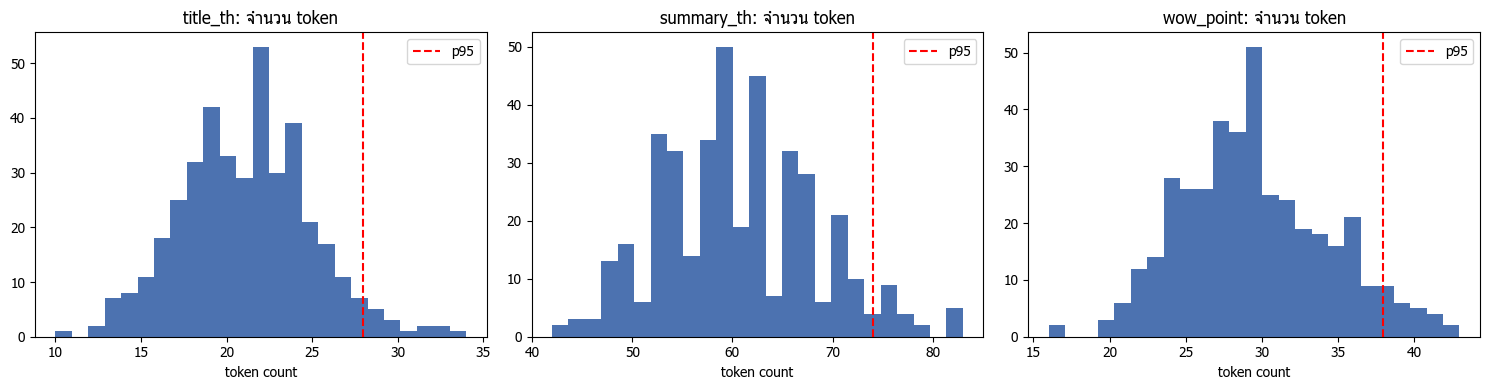

,char_p50,char_p95,token_p50,token_p90,token_p95,token_max
field,,,,,,
title_th,74.0,92.00,21.0,26.0,28.00,34
summary_th,217.0,255.05,60.0,71.0,74.05,83
wow_point,108.0,134.00,29.0,36.0,38.00,43


In [9]:
length_stats = []
fig, axes = plt.subplots(1, len(CONFIG.text_fields), figsize=(5 * len(CONFIG.text_fields), 4))
if len(CONFIG.text_fields) == 1:
    axes = [axes]

for ax, tf in zip(axes, CONFIG.text_fields):
    char_lens = df[tf].str.len()
    token_lens = df[f"{tf}_tokens"].apply(len)

    length_stats.append({
        "field": tf,
        "char_p50": char_lens.quantile(0.5),
        "char_p95": char_lens.quantile(0.95),
        "token_p50": token_lens.quantile(0.5),
        "token_p90": token_lens.quantile(0.9),
        "token_p95": token_lens.quantile(0.95),
        "token_max": token_lens.max(),
    })

    ax.hist(token_lens, bins=25, color="#4C72B0")
    ax.axvline(token_lens.quantile(0.95), color="red", linestyle="--", label="p95")
    ax.set_title(f"{tf}: จำนวน token")
    ax.set_xlabel("token count")
    ax.legend()

fig.tight_layout()
plt.show()

length_df = pd.DataFrame(length_stats).set_index("field")
length_df


In [10]:
recommended_max_length = int(length_df["token_p95"].sum() * 1.15)  # +15% กันเผื่อ system+special tokens
print(
    f"แนะนำ max_length (รวม 3 field, ครอบคลุม p95 ของแต่ละ field + เผื่อ 15% สำหรับ system prompt/special token): "
    f"~{recommended_max_length} tokens"
)


แนะนำ max_length (รวม 3 field, ครอบคลุม p95 ของแต่ละ field + เผื่อ 15% สำหรับ system prompt/special token): ~161 tokens


## 5. สถิติ Vocabulary

ขนาด vocab และ lexical diversity (type-token ratio = จำนวนคำไม่ซ้ำ / จำนวนคำทั้งหมด) บอกว่าเนื้อหาซ้ำซาก
(diversity ต่ำ) หรือหลากหลาย (diversity สูง) — ถ้าต่ำผิดปกติอาจแปลว่า Gemini เขียนวนซ้ำรูปแบบเดิม


In [11]:
vocab_stats = []
for tf in CONFIG.text_fields:
    all_tokens = [tok for toks in df[f"{tf}_tokens"] for tok in toks]
    vocab = set(all_tokens)
    ttr = len(vocab) / len(all_tokens) if all_tokens else 0
    vocab_stats.append({
        "field": tf,
        "total_tokens": len(all_tokens),
        "vocab_size": len(vocab),
        "type_token_ratio": round(ttr, 4),
    })

pd.DataFrame(vocab_stats).set_index("field")


,total_tokens,vocab_size,type_token_ratio
field,,,
title_th,8440,1743,0.2065
summary_th,24255,3046,0.1256
wow_point,11795,1873,0.1588


## 6. Top N-grams

ใช้ **กราฟแท่ง** แสดง unigram/bigram ที่พบบ่อยที่สุด แทน word cloud เพราะ bar chart จัดลำดับความถี่ได้ชัดเจน
วัดขนาดเปรียบเทียบกันได้จริง ในขณะที่ word cloud ให้แค่ความรู้สึกคร่าวๆ ไม่มีสเกลที่อ่านค่าได้

จุดที่ต้องดู: ถ้า top n-grams ของ `tags` (คำที่ใช้บ่อย) ไปซ้ำกับคำเด่นใน `summary_th` มาก แปลว่า tags
ไม่ได้เพิ่มข้อมูลใหม่เกินเนื้อหาที่มีอยู่แล้ว (อาจไม่ใช่ปัญหาแต่ควรรู้ไว้)


In [ ]:
THAI_CHAR_RE = re.compile(r"[฀-๿]")


def top_ngrams(token_lists, n: int, top_k: int, drop_stopwords: bool = True) -> list[tuple[str, int]]:
    counter = Counter()
    for tokens in token_lists:
        clean = [t.strip() for t in tokens if t.strip()]
        clean = [t for t in clean if THAI_CHAR_RE.search(t)]  # ตัดเครื่องหมาย/ตัวเลข/คำอังกฤษหลุด
        if drop_stopwords:
            clean = [t for t in clean if t not in THAI_STOPWORDS]
        for i in range(len(clean) - n + 1):
            counter[" ".join(clean[i : i + n])] += 1
    return counter.most_common(top_k)


fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, n, label in zip(axes, [1, 2], ["unigram", "bigram"]):
    grams = top_ngrams(df[f"{CONFIG.main_summary_field}_tokens"], n=n, top_k=CONFIG.top_n_ngrams)
    ax.barh([g for g, _ in grams][::-1], [c for _, c in grams][::-1], color="#55A868")
    ax.set_title(f"Top {label}s in `{CONFIG.main_summary_field}` (stopwords removed, bar chart)")

fig.tight_layout()
plt.show()


## 7. การกระจายของ category

เช็คว่าสัดส่วน category (cs.AI, cs.CL, ...) ตรงกับที่ script เก็บข้อมูลตั้งใจไว้หรือไม่
(ตาม `bulk-generate-dataset.ts` ที่ดึงจาก `cat:cs.CL OR cat:cs.AI` เป็นหลัก)


category
cs.AI              31.5%
cs.CL              19.0%
cs.LG              14.2%
cs.CV              10.0%
cs.RO               5.0%
cs.SE               4.2%
cs.SD               2.0%
cs.CR               2.0%
eess.AS             1.8%
cs.CY               1.5%
cs.IR               1.2%
cs.DB               0.8%
stat.ML             0.8%
cs.HC               0.5%
physics.chem-ph     0.5%
cs.DL               0.5%
eess.SP             0.5%
cs.DC               0.5%
cs.NE               0.5%
hep-ex              0.2%
quant-ph            0.2%
cs.IT               0.2%
physics.soc-ph      0.2%
cs.MA               0.2%
math.OC             0.2%
cs.LO               0.2%
econ.GN             0.2%
eess.IV             0.2%
eess.SY             0.2%
astro-ph.SR         0.2%
cs.AR               0.2%
Name: count, dtype: object


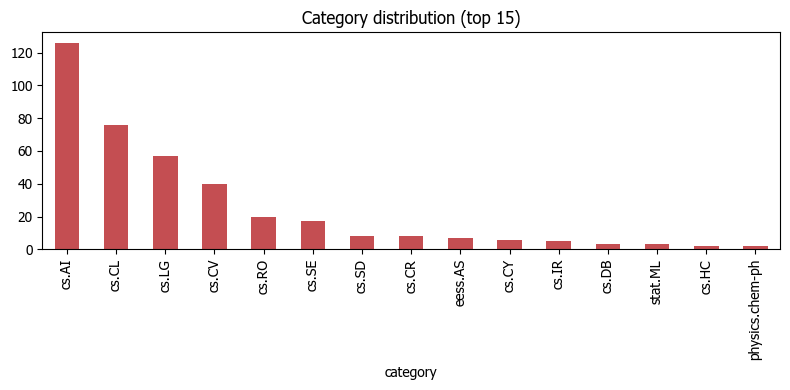

In [13]:
cat_counts = df[CONFIG.category_field].value_counts()
print((cat_counts / len(df) * 100).round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(8, 4))
cat_counts.head(15).plot(kind="bar", ax=ax, color="#C44E52")
ax.set_title("Category distribution (top 15)")
fig.tight_layout()
plt.show()


## 8. การกระจายตามวันที่ตีพิมพ์

ดูว่าข้อมูลกระจายครอบคลุมหลายช่วงเวลาไหม หรือกระจุกอยู่แค่ไม่กี่เดือน (ตามที่ตั้งใจผสม "ใหม่ + เก่า" ใน `bulk-generate-dataset.ts`)


ช่วงวันที่: 2026-06-17 ถึง 2026-07-06


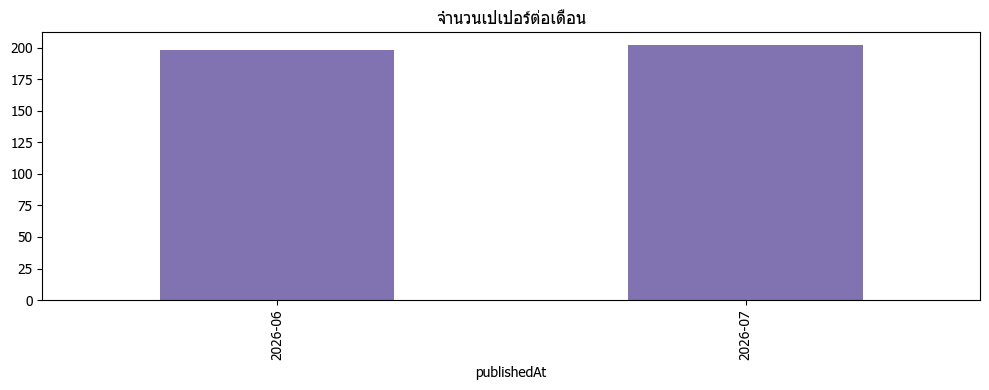

In [14]:
valid_dates = df[CONFIG.date_field].dropna()
print(f"ช่วงวันที่: {valid_dates.min().date()} ถึง {valid_dates.max().date()}")

by_month = valid_dates.dt.tz_localize(None).dt.to_period("M").value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
by_month.plot(kind="bar", ax=ax, color="#8172B2")
ax.set_title("จำนวนเปเปอร์ต่อเดือน")
fig.tight_layout()
plt.show()


## 9. ตรวจ duplicate / near-duplicate

เช็คทั้ง exact duplicate (summary เหมือนกันทุกตัวอักษร) และ near-duplicate (TF-IDF cosine similarity สูง)
เพื่อจับกรณี Gemini เขียนคำตอบคล้ายกันมากสำหรับเปเปอร์คนละใบ (ลด diversity ของ training data)


In [15]:
exact_dup_mask = df[CONFIG.main_summary_field].duplicated(keep=False) & (
    df[CONFIG.main_summary_field].fillna("") != ""
)
print(f"แถวที่มี summary ซ้ำกันทุกตัวอักษร: {exact_dup_mask.sum()}")

texts = df[CONFIG.main_summary_field].fillna("").tolist()
vectorizer = TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 4), min_df=1)
matrix = vectorizer.fit_transform(texts)
sims = cosine_similarity(matrix)

near_dup_pairs = []
n = len(texts)
for i in range(n):
    for j in range(i + 1, n):
        if sims[i, j] >= CONFIG.near_dup_threshold:
            near_dup_pairs.append((df.iloc[i][CONFIG.id_field], df.iloc[j][CONFIG.id_field], sims[i, j]))

near_dup_pairs.sort(key=lambda p: -p[2])
print(f"คู่ near-duplicate (cosine similarity >= {CONFIG.near_dup_threshold}): {len(near_dup_pairs)}")
for id_a, id_b, sim in near_dup_pairs[:10]:
    print(f"  {id_a} <-> {id_b}: {sim:.3f}")


แถวที่มี summary ซ้ำกันทุกตัวอักษร: 0


คู่ near-duplicate (cosine similarity >= 0.85): 0


## 10. ตัวอย่างข้อมูลแบบสุ่ม (อ่านเพื่อเช็คคุณภาพ/โทนภาษา)


In [16]:
sample = df.sample(n=min(CONFIG.sample_size, len(df)), random_state=CONFIG.random_seed)
for _, r in sample.iterrows():
    print(f"\n--- [{r[CONFIG.id_field]}] ({r[CONFIG.category_field]}) ---")
    for tf in CONFIG.text_fields:
        print(f"{tf}: {r[tf]}")
    print(f"tags: {r[CONFIG.tags_field]}")



--- [2607.01776] (cs.CY) ---
title_th: เมื่อ AI เริ่มนิยาม 'ความรู้ที่ดี' ใหม่ เราจะวัดคุณค่าของงานในอนาคตยังไง?
summary_th: ยุคนี้เราเริ่มตั้งคำถามกันแล้วว่าความรู้แบบไหนที่ 'มีค่า' จริงๆ แทนที่จะยึดติดกับมาตรฐานเดิมๆ งานนี้เขาใช้ digital humanities วิเคราะห์เทรนด์จากบทความวิจัยนับร้อย เพื่อหา Framework ใหม่ที่เน้นเรื่อง 'generativity' ของ AI แทนที่จะเป็นแค่ตัวช่วยแบบเดิมๆ
wow_point: เป็นการดึงเอาทักษะงานวิจัยมาใช้ตั้งคำถามว่า ต่อไปนี้ 'ความสร้างสรรค์' ที่ AI ทำได้ จะกลายเป็นบรรทัดฐานใหม่ของความรู้ที่มีคุณภาพแทนที่วิธีทำงานแบบเก่า
tags: ['AI', 'Generative AI', 'Future of Work', 'Digital Humanities']

--- [2606.20113] (cs.CL) ---
title_th: Streaming RAG จะฉลาดขึ้นไปอีก! แอบดึงข้อมูลก่อนพิมพ์จบทำได้จริงไหม?
summary_th: ปกติเวลาใช้ RAG เราต้องรอให้พิมพ์จบถึงจะหาข้อมูล แต่ paper นี้เสนอวิธีเดา 'intent' ตั้งแต่ยังพิมพ์ไม่เสร็จ เพื่อให้ดึงข้อมูลมารอไว้ล่วงหน้า ช่วยลดเวลาตอบสนองของ LLM ได้แบบเห็นผลสุดๆ
wow_point: พิสูจน์แล้วว่าคำถามส่วนใหญ่ 74% เราสามารถเดาใจผู้ใช้ได้ก่อนพิมพ์จบ ช่วยซ่อน la

## สรุปผล (ภาษาไทย แบบเข้าใจง่าย)

- **ขนาดข้อมูล**: ดูจาก `df.shape` ด้านบน — ถ้าน้อยกว่าหลักพัน ก็ยังใช้เทรนแบบ QLoRA (fine-tune สไตล์/ฟอร์แมต) ได้ตามปกติ
- **ความยาว**: ใช้ค่า `recommended_max_length` ที่คำนวณไว้ด้านบนเป็นค่าตั้งต้นสำหรับ `max_length` ตอนเทรน —
  มาจาก p95 ของแต่ละ field บวก buffer กันข้อความยาวผิดปกติ (outlier) ถูกตัดทิ้งระหว่างเทรน
- **Vocab/ความหลากหลาย**: ถ้า type-token ratio ต่ำมากในบาง field แปลว่าเนื้อหาซ้ำรูปแบบเดิมบ่อย ควรดูตัวอย่างจริงประกอบ
- **Category**: สัดส่วนควรสอดคล้องกับที่ script ดึงข้อมูลตั้งใจไว้ (cs.AI/cs.CL เป็นหลัก) ถ้าเบี้ยวไปทาง category อื่นมาก
  ควรเช็คว่า `bulk-generate-dataset.ts` ดึงถูก query หรือไม่
- **Duplicate**: ถ้าเจอ exact/near-duplicate เยอะ ควรพิจารณาตัดออกก่อนเทรน เพราะจะทำให้โมเดลเห็นตัวอย่างเดิมซ้ำๆ
  โดยไม่ได้เพิ่มความหลากหลายจริง

ขั้นถัดไป: ใช้ `recommended_max_length` ตอนตั้งค่า tokenizer ใน Stage 2 (เทรนบน Colab)
